In [1]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem
import fig_utils as fu

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



In [2]:
ds_LUT = {
#         '20240623':{'ds':'MNIST', 'dist':'D1'},
#           '20240707':{'ds':'MNIST', 'dist':'D2'},
# #           '20240621':{'ds':'FMNIST_old', 'dist':'D1'},
#           '20240801':{'ds':'FMNIST', 'dist':'D1'},
# #           '20240708':{'ds':'FMNIST_old', 'dist':'D2'},
#           '20240728':{'ds':'FMNIST', 'dist':'D2'},
#           '20240703':{'ds':'KMNIST', 'dist':'D1'},
#           '20240705':{'ds':'KMNIST', 'dist':'D2'},
          '20250724':{'ds':'MNIST', 'dist':'D1'},
          '20250809':{'ds':'MNIST', 'dist':'D2'},
#           '20240621':{'ds':'FMNIST_old', 'dist':'D1'},
          '20250803':{'ds':'FMNIST', 'dist':'D1'},
#           '20240708':{'ds':'FMNIST_old', 'dist':'D2'},
          '20250810_2':{'ds':'FMNIST', 'dist':'D2'},
          '20250730_2':{'ds':'KMNIST', 'dist':'D1'},
          '20250909':{'ds':'KMNIST', 'dist':'D2'},
         }

In [3]:
min_epoch = 0
use_test = True
search_paths = {'contrastive_XL':'../wexac_saved_runs/',
                'contrastive':'../wexac_saved_runs/',
                'reference': '../bnassa_saved_runs/acc_vs_events_num/',
               }
# ref_config_paths = {'full_table':'../wexac_saved_runs/contrast_sweep_seeds861123_1/config.yaml',
#                       }
ref_config_paths = {'contrastive':'../wexac_saved_runs/contrast_rev2p3_sweep_seeds_and_ds__1262022//config.yaml',
                    'contrastive_XL':'../wexac_saved_runs/contrast_rev2p3_sweep_seeds_and_ds_big__1261722/config.yaml',
                    # 'reference':'../wexac_saved_runs/all_ds_x2x2__198232/config.yaml',
                    'reference':'../bnassa_saved_runs/acc_vs_events_num/ebtKMNISTD2_20250909_supervised_sweep_833983/config.yaml'
                      }



config_ignore_fields_s = {'contrastive':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path','run_name_history','job_id',
                                       'pretrained_model_path','train_head_only','job_id_suffix','resume_run_name','model_args_offsets'],
                          'contrastive_XL':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path','run_name_history','job_id',
                                       'pretrained_model_path','train_head_only','job_id_suffix','resume_run_name','model_args_offsets'],
                          'reference':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path','run_name_history','job_id',
                                       'pretrained_model_path','train_head_only','job_id_suffix','resume_run_name', 'config_file','model_args_offsets']
                          }
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = fu.analyze_runs(ref_config_path, search_paths[this_mode], config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')

found 60 runs for mode contrastive
found 60 runs for mode contrastive_XL
found 210 runs for mode reference


In [4]:
def squeeze_dict(d):
    return d[[k for k in d.keys()][0]]

In [5]:
for k in dfs:
    dfs[k]['mode'] =  k + ' ' +dfs[k]['train_head_only'].astype(str)

In [6]:

df = pd.concat(dfs.values(), ignore_index=True)

In [7]:
# n_samples_s = df['ds_args_n_samples'].unique()
n_samples_s = [48]
data_paths = df['eb_ds_path'].unique()
modes = df['mode'].unique()

In [8]:
dd = {}
for n_samples in n_samples_s:
    for data_path in data_paths:
        for mode in modes:
            print(f'processing n_samples {n_samples}, data_path {data_path} mode {mode}')
            try:
                dd[(data_path.split('/')[-1],n_samples, mode)] = \
                df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
                aggregate({'test_acc':[lambda x: fu.mean_std_of_not_too_low(x)[0],
                                       lambda x: fu.mean_std_of_not_too_low(x)[1],
                                       lambda x: fu.mean_std_of_not_too_low(x)[2],
                                      lambda x: fu.mean_std_of_not_too_low(x)[3],]+ ['median','mean','std','sem']})
                print('success')
            except:
                print(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode])
                print('failed')

processing n_samples 48, data_path /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250809 mode contrastive False
success
processing n_samples 48, data_path /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250809 mode contrastive True
success
processing n_samples 48, data_path /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250809 mode contrastive_XL True
success
processing n_samples 48, data_path /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250809 mode contrastive_XL False
success
processing n_samples 48, data_path /home/labs/ahissarlab/bnassa/datasets/eb_datasets/20250809 mode reference False
Empty DataFrame
Columns: [batch_size, check_job_recovery, config_file, dataset, disable_data_parallel, do_warmup, ds_args_n_samples, ds_args_one_hot_coordinates, ds_args_shuffle_events, ds_args_train_from_time_interval, ds_args_val_start_time, ds_test_subdir, ds_train_subdir, eb_ds_path, eb_ds_time_align_by_imu_edge, eb_ds_ts_jitter, en_autodetect_offsets, epochs, eval, flatten_

/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb

success
processing n_samples 48, data_path ../datasets/eb_datasets/20250803 mode contrastive False
Empty DataFrame
Columns: [batch_size, check_job_recovery, config_file, dataset, disable_data_parallel, do_warmup, ds_args_n_samples, ds_args_one_hot_coordinates, ds_args_shuffle_events, ds_args_train_from_time_interval, ds_args_val_start_time, ds_test_subdir, ds_train_subdir, eb_ds_path, eb_ds_time_align_by_imu_edge, eb_ds_ts_jitter, en_autodetect_offsets, epochs, eval, flatten_contrastive_input, job_id, job_id_suffix, json_log, json_test_data, loss_args_p_drop_negative_samples, loss_args_temperature, lr, model, model_args_d_timeseries, model_args_dropout_rate, model_args_model_head, model_args_num_classes, model_args_offsets, model_args_scalings, momentum, n_validation, no_cuda, num_workers, pretrained_model_no_head, pretrained_model_path, resume_run_name, run_name, run_name_history, save_path, seed, supervision_mode, tag, train_head_only, use_sgd, epoch, test_loss, test_acc, test_avg_ac

/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode].\
/tmp/ipykernel_1911165/423354012.py:9: FutureWarning: using <function <lambda> at 0x7e0bba6c04c0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  aggregate({'test_acc':[lambda x: fu.mean_std_of_not_too_low(x)[0],
/tmp/ipykernel_1911165/423354012.py:9: FutureWarning: using <function <lambda> at 0x7e0bba6c1090> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  aggregate({'test_acc':[lambda x: fu.mean_std_of_not_too_low(x)[0],
/tmp/ipykernel_1911165/423354012.py:9:

In [9]:
df_prep = []

for ds_date,ds in ds_LUT.items():
    for n_samples in n_samples_s:
        for mode in modes:
            my_key = (ds_date,n_samples, mode)
            df_prep.append([ds['ds'], ds['dist'],mode,n_samples,
                            f'{dd[my_key].iloc[0,0]:.3f}',
                            f'{dd[my_key].iloc[1,0]:.3f}',
                            f'{dd[my_key].iloc[2,0]:.3f}',
                            f'{dd[my_key].iloc[3,0]:.3f}',
                            ds_date])

In [10]:
dfsum = pd.DataFrame(df_prep, columns = ['Dataset', 'Distance','Mode', 'n_events' ,'AccMean','AccStd','AccCnt','AccSem','Date'])

In [11]:
mode_LUT = {'contrastive True': 'contrastive\n finetune head',
           'contrastive False': 'contrastive\n finetune all',
            'contrastive_XL True': 'contrastive XL\n finetune head',
           'contrastive_XL False': 'contrastive XL\n finetune all',
           'reference False': 'reference'}

mode_order = [ 'contrastive\n finetune head',
            'contrastive XL\n finetune head', 
            'reference',
            'contrastive\n finetune all' ,
            'contrastive XL\n finetune all' ,
             ]
dfsum['Mode']=dfsum['Mode'].replace(mode_LUT)
dfsum['Mode'] = pd.Categorical(dfsum['Mode'], categories=mode_order, ordered=True)

In [12]:
dfsum = dfsum.sort_values(by=['n_events','Dataset','Mode'])

/tmp/ipykernel_1911165/2648069147.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(uu['Mode'].to_numpy(), rotation=40)
/tmp/ipykernel_1911165/2648069147.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(uu['Mode'].to_numpy(), rotation=40)
/tmp/ipykernel_1911165/2648069147.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(uu['Mode'].to_numpy(), rotation=40)
/tmp/ipykernel_1911165/2648069147.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(uu['Mode'].to_numpy(), rotation=40)
/tmp/ipykernel_1911165/2648069147.py:41: UserWarning: set_ticklabels() should only be used with 

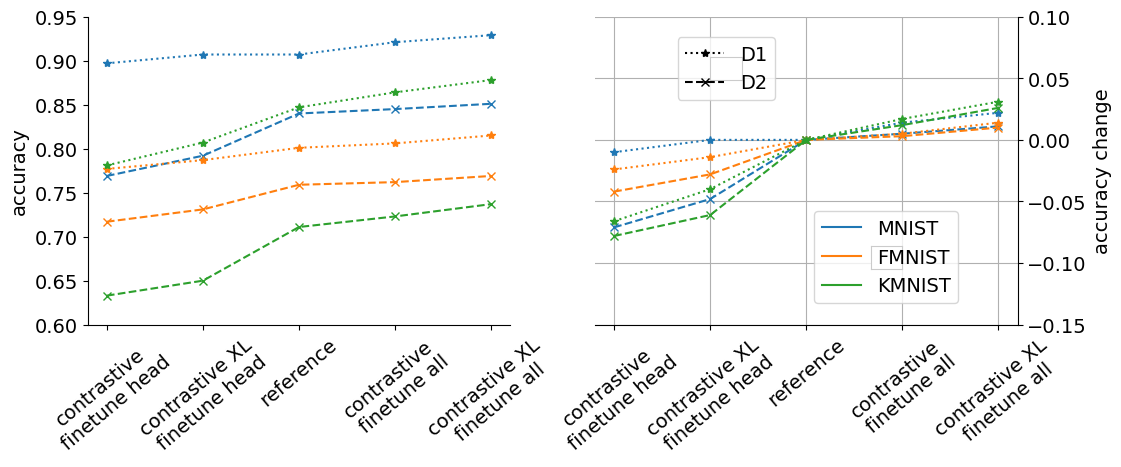

In [13]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 14})


for do_diff in [0,1]:
    styles = [':*','--x']
    # these_ds = dfsum['Dataset'].unique()
    these_ds = ['MNIST','FMNIST','KMNIST']#,'FMNIST_new']
    colors = []

    for aaa, this_ds in enumerate(these_ds):
        plt.subplot(1,2,do_diff+1)

        sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
        ddd = sorted(sub_df['Distance'].unique())

        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle
        colors.append(color)

        for dd,this_dist in enumerate(ddd):
#             plt.subplot(1,2,1)
            uu = sub_df.loc[sub_df['Distance']==this_dist]
            y = uu['AccMean'].astype(float).to_numpy()
            if do_diff:
                y -= y[2]

            plt.plot(uu['Mode'].to_numpy(), y,styles[dd],
                     color=color,label=this_ds)
    #         fb_baseline = frames_LUT[(this_ds,this_dist)]
    #         plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
    #                  ':', linewidth=2,
    #                  color=color)

    #         plt.xlabel('number of events')
            if do_diff == 0:
                plt.ylim(0.60,0.95)
            elif do_diff == 1:
                plt.ylim(-0.15,0.1)

            ax = plt.gca()
            ax.set_xticklabels(uu['Mode'].to_numpy(), rotation=40)
            ax.spines[['right', 'top']].set_visible(False)
    # plt.legend()
    ax = plt.gca()
    # ax.spines[['left','right', 'top']].set_visible(False)

    # plt.yticks([0.5,1])
plt.subplot(1,2,1)
plt.ylabel('accuracy')
ax = plt.gca()
plt.subplot(1,2,2)
plt.ylabel('accuracy change')
ax = plt.gca()
ax.yaxis.set_label_position('right')
ax.yaxis.set_ticks_position('right')

ax.spines[['right']].set_visible(True)
ax.spines[['left']].set_visible(False)
ax.grid()


# add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
#                        titles = ['event based', 'frame based baseline'] ,
#                        bbox=(0.25,0.15,0.5,0.5))

fu.add_inset_with_symbols(ax, width="15%", height="15%", loc=2, styles=[s+'k' for s in styles], 
                       titles = ['D1', 'D2'] ,
                       bbox=(0.25,0.4,0.5,0.5))
fu.add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=colors, 
                       titles = these_ds ,
                       bbox=(0.25,0.15,0.5,0.5))
 

In [14]:

# Create an empty list to hold table rows
table_rows = []

# Iterate over the datasets and distances to construct the table
for this_ds in ['MNIST', 'FMNIST', 'KMNIST']:
    sub_df = dfsum.loc[dfsum['Dataset'] == this_ds]
    ddd = sorted(sub_df['Distance'].unique())

    for this_dist in ddd:
        uu = sub_df.loc[sub_df['Distance'] == this_dist]
        
        # Ensure 'AccMean' is numeric
        uu['AccMean'] = pd.to_numeric(uu['AccMean'], errors='coerce')

        # For each mode, calculate the metrics
        for mode, N, acc_mean, acc_std,acc_sem in zip(uu['Mode'],uu['AccCnt'], uu['AccMean'], uu['AccStd'],uu['AccSem']):
            # Calculate accuracy change if needed (e.g., normalized by the third mode)
            baseline_acc = uu['AccMean'].iloc[2] if len(uu) > 2 else 0  # Avoid index errors
            accuracy_change = acc_mean - baseline_acc

            # Append a row to the table
            table_rows.append({
                'Dataset': this_ds,
                'Distance': this_dist,
                'Mode': mode,
                'N Runs': N,
                'Accuracy Mean': acc_mean,
                'Accuracy STD': acc_std,
                'Accuracy SEM': acc_sem,
                'Accuracy Change': accuracy_change
            })

# Create a DataFrame from the collected rows
results_table = pd.DataFrame(table_rows)

# Display the table to the user
# import ace_tools as tools; tools.display_dataframe_to_user(name="Results Table", dataframe=results_table)


/tmp/ipykernel_1911165/918782990.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uu['AccMean'] = pd.to_numeric(uu['AccMean'], errors='coerce')


In [15]:
results_table

,Dataset,Distance,Mode,N Runs,Accuracy Mean,Accuracy STD,Accuracy SEM,Accuracy Change
0,MNIST,D1,contrastive\n finetune head,5.000,0.897,0.001,0.000,-0.010
1,MNIST,D1,contrastive XL\n finetune head,5.000,0.907,0.002,0.001,0.000
2,MNIST,D1,reference,5.000,0.907,0.001,0.001,0.000
3,MNIST,D1,contrastive\n finetune all,5.000,0.921,0.002,0.001,0.014
4,MNIST,D1,contrastive XL\n finetune all,5.000,0.929,0.001,0.001,0.022
5,MNIST,D2,contrastive\n finetune head,5.000,0.769,0.002,0.001,-0.071
6,MNIST,D2,contrastive XL\n finetune head,5.000,0.792,0.003,0.001,-0.048
7,MNIST,D2,reference,5.000,0.840,0.002,0.001,0.000
8,MNIST,D2,contrastive\n finetune all,5.000,0.845,0.002,0.001,0.005
9,MNIST,D2,contrastive XL\n finetune all,5.000,0.851,0.002,0.001,0.011


In [16]:
from fig_utils import pvals_by_row,p_to_stars, bar_plots_with_significances, add_manual_legend

In [17]:
latex_out = fu.df_to_latex_table(results_table, column_formats={'N Runs':'.0f'})

In [18]:
print(latex_out)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c | c}
\hline
\makecell{Dataset} & \makecell{Distance} & \makecell{Mode} & \makecell{N \\ Runs} & \makecell{Accuracy \\ Mean} & \makecell{Accuracy \\ STD} & \makecell{Accuracy \\ SEM} & \makecell{Accuracy \\ Change} \\
\hline
MNIST & D1 & contrastive
 finetune head & 5 & 0.897 & 0.001 & 0.000 & -0.010 \\
\hline
MNIST & D1 & contrastive XL
 finetune head & 5 & 0.907 & 0.002 & 0.001 & 0.000 \\
\hline
MNIST & D1 & reference & 5 & 0.907 & 0.001 & 0.001 & 0.000 \\
\hline
MNIST & D1 & contrastive
 finetune all & 5 & 0.921 & 0.002 & 0.001 & 0.014 \\
\hline
MNIST & D1 & contrastive XL
 finetune all & 5 & 0.929 & 0.001 & 0.001 & 0.022 \\
\hline
MNIST & D2 & contrastive
 finetune head & 5 & 0.769 & 0.002 & 0.001 & -0.071 \\
\hline
MNIST & D2 & contrastive XL
 finetune head & 5 & 0.792 & 0.003 & 0.001 & -0.048 \\
\hline
MNIST & D2 & reference & 5 & 0.840 & 0.002 & 0.001 & 0.000 \\
\hline
MNIST & D2 & contrastive
 finetune all & 

In [19]:
clean_ds_names = [d for d in set([ data_path.split('/')[-1] for data_path in data_paths])]
#sort by dataset name, e.g. mnist, then by distance e.g. D2
source_ds_ordering = {'MNIST':0,'FMNIST':1,'KMNIST':2}
clean_ds_names.sort(key=lambda n: (ds_LUT[n]['dist'], source_ds_ordering[ds_LUT[n]['ds']]))

ds_idxs = {name:idx for idx,name in enumerate(clean_ds_names)}
idxs_to_ds = {v:k for k,v in ds_idxs.items()}

In [20]:
modes, mode_order, mode_LUT
mode_inv_LUT = {v:k for k,v in mode_LUT.items()}
#sort modes according to the mode_order, and using the LUT

modes = [mode_inv_LUT[mm] for mm in mode_order]

In [21]:
dd = {}
data_as_np = np.nan*np.ones([len(clean_ds_names), len(modes), 5])
for n_samples in n_samples_s:
    for data_path in data_paths:
        data_key = data_path.split('/')[-1]
        ddid = ds_idxs[data_key]
        for mm, mode in enumerate(modes):
            # print(f'processing n_samples {n_samples}, data_path {data_path} mode {mode}')
            try:
                data_as_np[ddid,mm,:] = np.array(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode]['test_acc'])
            except:
                pass

/tmp/ipykernel_1911165/3400256726.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_as_np[ddid,mm,:] = np.array(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode]['test_acc'])
/tmp/ipykernel_1911165/3400256726.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_as_np[ddid,mm,:] = np.array(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode]['test_acc'])
/tmp/ipykernel_1911165/3400256726.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_as_np[ddid,mm,:] = np.array(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']==mode]['test_acc'])
/tmp/ipykernel_1911165/3400256726.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_as_np[ddid,mm,:] = np.array(df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path][df['mode']=

In [22]:
from scipy.stats import ranksums

In [23]:
def tensor_to_barplot_inputs(
    data_gcm,                 # (g, n, m): groups × conditions × datapoints
    *,
    ref_condition,            # int index OR str label (if condition_labels provided)
    condition_labels=None,    # optional list[str] length n
    test=ranksums,            # ranksums or wilcoxon etc. (must return (stat,p))
):
    """
    Uses your existing helpers: pvals_by_row + p_to_stars.
    No NaN safety / checks (as requested).

    Returns:
      bar_vals_by_group   : (g, n) means over m
      yerr_by_group       : (g, n) SEM over m
      sig_markers_by_group: (g, n) stars vs reference within each group
      pvals_by_group      : (g, n) p-values vs reference (nan for reference)
      ref_idx             : int
    """
    x = np.asarray(data_gcm, dtype=float)
    g, n, m = x.shape

    # resolve reference index
    if isinstance(ref_condition, str):
        ref_idx = condition_labels.index(ref_condition)
    else:
        ref_idx = int(ref_condition)

    # mean + SEM across datapoints
    bar_vals = x.mean(axis=2)                          # (g, n)
    yerr = x.std(axis=2, ddof=1) / np.sqrt(m)          # (g, n)

    # p-values and stars vs reference, computed *within each group*
    pvals = np.full((g, n), np.nan, dtype=float)
    stars = np.full((g, n), "", dtype=object)

    # reference samples for all groups: (g, m)
    ref = x[:, ref_idx, :]

    for ci in range(n):
        if ci == ref_idx:
            continue
        alt = x[:, ci, :]                               # (g, m)
        this_p = pvals_by_row(ref, alt, test=test)      # (g,)
        pvals[:, ci] = this_p
        stars[:, ci] = [p_to_stars(p) for p in this_p]

    return bar_vals, yerr, stars, pvals, ref_idx

(0.0, 1.15)

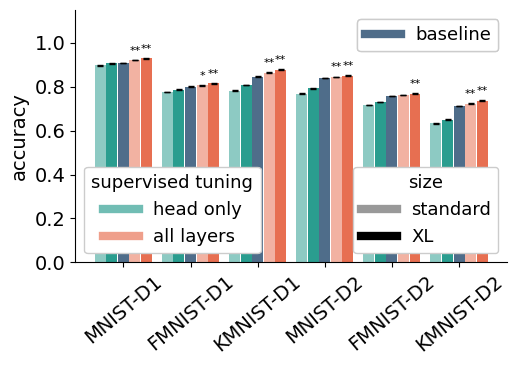

In [24]:
# data_gcm: (g, n_conditions, m_runs)
bar_vals, bar_sem, sig_mark, pvals, ref_idx = tensor_to_barplot_inputs(
    data_as_np,
    ref_condition=2,      # or an int
    condition_labels=modes,    # needed only if ref_condition is a string
    test=ranksums,                  # or wilcoxon
)

sig_mark[:,:3] = ''
group_labels =  [f"{ds_LUT[idxs_to_ds[i]]['ds']}-{ds_LUT[idxs_to_ds[i]]['dist']}" for i in range(6)]
fig, ax = bar_plots_with_significances(
    bar_vals,
    sig_mark,
    ['#2A9D8F88','#2A9D8F','#4F6D8A','#E76F5188','#E76F51'], #colorcodes,
    group_labels,#group_labels,
    yerr_by_group=bar_sem,
    group_x=None, #group_x,
    chance_line=None,#0.5,
    ylim=(0, 1.05),
    fontsize=13,
    fontsize_stars=8,
    figsize=(5.2, 3.2),
)

ax.set_xticklabels(group_labels, rotation=40)

leg1 = add_manual_legend(
    ax,
    labels=["head only",  "all layers"],
    colorcodes=['#2A9D8FAA','#E76F51AA'],
    title="supervised tuning",
    loc="lower left",
    add_artist=True,    
)

leg2 = add_manual_legend(
    ax,
    labels=["standard",  "XL"],
    colorcodes=['#00000066','k'],
    title="size",
    loc="lower right",
    add_artist=True,   # keep when adding the second legend
)

leg2 = add_manual_legend(
    ax,
    labels=["baseline"],
    colorcodes=['#4F6D8A'],
    loc="upper right",
    add_artist=True,   # keep when adding the second legend
)
ax.set_ylabel('accuracy')
ax.set_ylim([0,1.15])

(-0.08, 0.08)

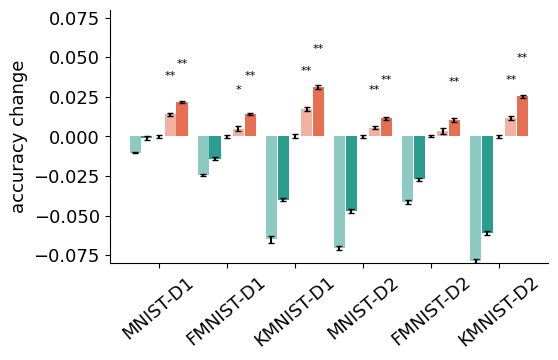

In [25]:
# data_gcm: (g, n_conditions, m_runs)
bar_vals, bar_sem, sig_mark, pvals, ref_idx = tensor_to_barplot_inputs(
    data_as_np,
    ref_condition=2,      # or an int
    condition_labels=modes,    # needed only if ref_condition is a string
    test=ranksums,                  # or wilcoxon
)

sig_mark[:,:3] = ''
group_labels =  [f"{ds_LUT[idxs_to_ds[i]]['ds']}-{ds_LUT[idxs_to_ds[i]]['dist']}" for i in range(6)]
fig, ax = bar_plots_with_significances(
    bar_vals-bar_vals[:,[2]],
    sig_mark,
    ['#2A9D8F88','#2A9D8F','#4F6D8A','#E76F5188','#E76F51'], #colorcodes,
    group_labels,#group_labels,
    yerr_by_group=bar_sem,
    group_x=None, #group_x,
    chance_line=None,#0.5,
    ylim=(0, 1.05),
    fontsize=13,
    fontsize_stars=8,
    figsize=(5.2, 3.2),
)

ax.set_xticklabels(group_labels, rotation=40)

# leg1 = add_manual_legend(
#     ax,
#     labels=["head only",  "all layers"],
#     colorcodes=['#2A9D8FAA','#E76F51AA'],
#     title="supervised tuning",
#     loc="lower left",
#     add_artist=True,    
# )

# leg2 = add_manual_legend(
#     ax,
#     labels=["standard",  "XL"],
#     colorcodes=['#00000066','k'],
#     title="size",
#     loc="lower right",
#     add_artist=True,   # keep when adding the second legend
# )

# leg2 = add_manual_legend(
#     ax,
#     labels=["baseline"],
#     colorcodes=['#4F6D8A'],
#     loc="upper right",
#     add_artist=True,   # keep when adding the second legend
# )
ax.set_ylabel('accuracy change')
ax.set_ylim([-0.08,0.08])

In [31]:
def sig_bracket(x1,x2, h=1.0, d=0.025):
    ax = plt.gca()
    uu = ax.plot((x1,x1,x2,x2),(h-d,h,h,h-d), 'k')
    uu[0].set_clip_on(False)


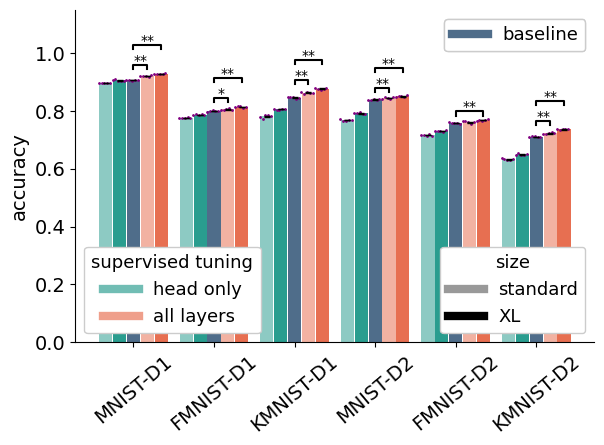

In [88]:
# data_gcm: (g, n_conditions, m_runs)
plt.rcParams.update({'font.size': 14})

group_width=0.86


bar_vals, bar_sem, sig_mark, pvals, ref_idx = tensor_to_barplot_inputs(
    data_as_np,
    ref_condition=2,      # or an int
    condition_labels=modes,    # needed only if ref_condition is a string
    test=ranksums,                  # or wilcoxon
)

sig_mark[:,:3] = ''
group_labels =  [f"{ds_LUT[idxs_to_ds[i]]['ds']}-{ds_LUT[idxs_to_ds[i]]['dist']}" for i in range(6)]
fig, ax = bar_plots_with_significances(
    bar_vals,
    np.full(sig_mark.shape, ''),
    ['#2A9D8F88','#2A9D8F','#4F6D8A','#E76F5188','#E76F51'], #colorcodes,
    group_labels,#group_labels,
    yerr_by_group=bar_sem,
    group_x=None, #group_x,
    chance_line=None,#0.5,
    group_width=group_width,
    ylim=(0, 1.05),
    fontsize=13,
    fontsize_stars=8,
    figsize=(6, 4),
)

ax.set_xticklabels(group_labels, rotation=40)

leg1 = add_manual_legend(
    ax,
    labels=["head only",  "all layers"],
    colorcodes=['#2A9D8FAA','#E76F51AA'],
    title="supervised tuning",
    loc="lower left",
    add_artist=True,    
)

leg2 = add_manual_legend(
    ax,
    labels=["standard",  "XL"],
    colorcodes=['#00000066','k'],
    title="size",
    loc="lower right",
    add_artist=True,   # keep when adding the second legend
)

leg2 = add_manual_legend(
    ax,
    labels=["baseline"],
    colorcodes=['#4F6D8A'],
    loc="upper right",
    add_artist=True,   # keep when adding the second legend
)
ax.set_ylabel('accuracy')
ax.set_ylim([0,1.15])



ref_id = 2 #second column counting from 0
n_groups = bar_vals.shape[0]
n = bar_vals.shape[1] 
delta_x = group_width/n
ref_x = delta_x*(ref_id+1/2-n/2)
delta_h = 0.07
for ii_, these_sig_marks in enumerate(sig_mark):
    ii =  ii_ - 1
    h0 = np.max(bar_vals[ii_])
    cnt = 0
    for jj, this_sig_mark in enumerate(these_sig_marks):
        if this_sig_mark !='':
            this_x =  delta_x*(jj+1/2-n/2)
            x1,x2 = (ii+1)+ref_x, (ii+1)+this_x
            h = h0+0.03+delta_h*cnt
            sig_bracket(x1,x2, h=h, d=0.015)
            # plt.text( (x1+x2)/2,h,'p<0.3', horizontalalignment='center',fontsize=10)
            plt.text( (x1+x2)/2,h,this_sig_mark, horizontalalignment='center',fontsize=10)
            cnt += 1

# #-----------------------plotting individual points

for offset_idx,data0 in enumerate(data_as_np):
    rev_offset_idx = offset_idx
    for jit_lay_ix, data1 in enumerate(data0):
        
        # this_x =  rev_offset_idx+delta_x*(jit_lay_ix+1/2-n/2) + delta_x*np.arange(len(data1))/len(data1)
        this_x =  rev_offset_idx+delta_x*(jit_lay_ix-n/2) + delta_x*np.arange(len(data1))/len(data1)
        # plt.plot(this_x*np.ones_like(data1),data1, '.',color='purple', markersize=2)
        plt.plot(this_x,data1, '.',color='purple', markersize=2)

# plt.savefig('fig3paneC.svg',format='svg')


In [55]:
m_names = group_labels
k_names = ['head_standard', 'head_XL','baseline', 'all_layers_standard', 'all_layers_XL']

In [83]:
import pandas as pd
from scipy.stats import ranksums
baseline_k_idx = 2
rows = []

for m_idx, m_name in enumerate(m_names):
    for k_idx, k_name in enumerate(k_names):

        values = data_as_np[m_idx, k_idx, :]  # shape (N,)

        baseline = data_as_np[m_idx, baseline_k_idx, :]

        if k_idx == baseline_k_idx:
            p_value = np.nan
        else:
            try:
                _, p_value = ranksums(
                    values,
                    baseline,
                    alternative="two-sided",
                )
            except ValueError:
                p_value = 1.0

        row = {
            "dataset": m_name,
            "configuration": k_name,
            "ranksums_p_vs_baseline": p_value,
        }

        row.update({
            f"seed_{seed + 1}": values[seed]
            for seed in range(values.shape[0])
        })

        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("fig4panelCD.csv", index=False)

In [84]:
df

,dataset,configuration,ranksums_p_vs_baseline,seed_1,seed_2,seed_3,seed_4,seed_5
0,MNIST-D1,head_standard,0.009023,0.8959,0.8970,0.8976,0.8972,0.8982
1,MNIST-D1,head_XL,0.464702,0.9082,0.9104,0.9058,0.9045,0.9040
2,MNIST-D1,baseline,NaN,0.9086,0.9074,0.9054,0.9094,0.9065
3,MNIST-D1,all_layers_standard,0.009023,0.9208,0.9200,0.9228,0.9188,0.9248
4,MNIST-D1,all_layers_XL,0.009023,0.9280,0.9283,0.9301,0.9289,0.9314
5,FMNIST-D1,head_standard,0.009023,0.7766,0.7758,0.7765,0.7785,0.7763
6,FMNIST-D1,head_XL,0.009023,0.7850,0.7886,0.7849,0.7886,0.7878
7,FMNIST-D1,baseline,NaN,0.7984,0.7999,0.8034,0.8019,0.8015
8,FMNIST-D1,all_layers_standard,0.028280,0.8031,0.8032,0.8063,0.8117,0.8048
9,FMNIST-D1,all_layers_XL,0.009023,0.8157,0.8162,0.8160,0.8119,0.8159


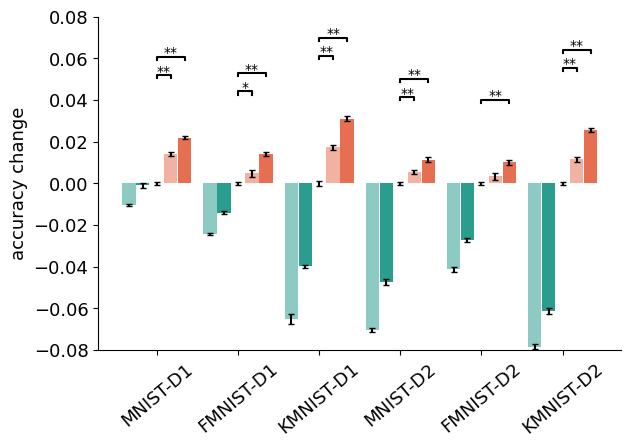

In [89]:
# data_gcm: (g, n_conditions, m_runs)
group_width=0.86


bar_vals, bar_sem, sig_mark, pvals, ref_idx = tensor_to_barplot_inputs(
    data_as_np,
    ref_condition=2,      # or an int
    condition_labels=modes,    # needed only if ref_condition is a string
    test=ranksums,                  # or wilcoxon
)
bar_vals = bar_vals-bar_vals[:,[2]]
sig_mark[:,:3] = ''
group_labels =  [f"{ds_LUT[idxs_to_ds[i]]['ds']}-{ds_LUT[idxs_to_ds[i]]['dist']}" for i in range(6)]
fig, ax = bar_plots_with_significances(
    bar_vals,
    np.full(sig_mark.shape, ''),
    ['#2A9D8F88','#2A9D8F','#4F6D8A','#E76F5188','#E76F51'], #colorcodes,
    group_labels,#group_labels,
    yerr_by_group=bar_sem,
    group_x=None, #group_x,
    chance_line=None,#0.5,
    group_width=group_width,
    ylim=(0, 1.05),
    fontsize=13,
    fontsize_stars=8,
    figsize=(6, 4),
)

ax.set_xticklabels(group_labels, rotation=40)


ax.set_ylabel('accuracy change')
ax.set_ylim([-0.08,0.08])



ref_id = 2 #second column counting from 0
n_groups = bar_vals.shape[0]
n = bar_vals.shape[1] 
delta_x = group_width/n
ref_x = delta_x*(ref_id+1/2-n/2)
delta_h = 0.07/8
for ii_, these_sig_marks in enumerate(sig_mark):
    ii =  ii_ - 1
    h0 = np.max(bar_vals[ii_])
    cnt = 0
    for jj, this_sig_mark in enumerate(these_sig_marks):
        if this_sig_mark !='':
            this_x =  delta_x*(jj+1/2-n/2)
            x1,x2 = (ii+1)+ref_x, (ii+1)+this_x
            h = h0+0.03+delta_h*cnt
            sig_bracket(x1,x2, h=h, d=0.0015)
            # plt.text( (x1+x2)/2,h,'p<0.3', horizontalalignment='center',fontsize=10)
            plt.text( (x1+x2)/2,h,this_sig_mark, horizontalalignment='center',fontsize=10)
            cnt += 1

# #-----------------------plotting individual points

for offset_idx,data0 in enumerate(data_as_np):
    rev_offset_idx = offset_idx
    for jit_lay_ix, data1 in enumerate(data0):
        
        # this_x =  rev_offset_idx+delta_x*(jit_lay_ix+1/2-n/2) + delta_x*np.arange(len(data1))/len(data1)
        this_x =  rev_offset_idx+delta_x*(jit_lay_ix-n/2) + delta_x*np.arange(len(data1))/len(data1)
        # plt.plot(this_x*np.ones_like(data1),data1, '.',color='purple', markersize=2)
        plt.plot(this_x,data1, '.',color='purple', markersize=2)

plt.savefig('fig3paneD.svg',format='svg')


In [72]:
bar_vals

array([[0.89718, 0.90658, 0.90746, 0.92144, 0.92934],
       [0.77674, 0.78698, 0.80102, 0.80582, 0.81514],
       [0.78144, 0.80662, 0.8465 , 0.8639 , 0.8776 ],
       [0.7691 , 0.79234, 0.83958, 0.8451 , 0.8509 ],
       [0.71734, 0.73142, 0.75862, 0.76208, 0.7688 ],
       [0.63276, 0.65008, 0.71126, 0.72288, 0.7367 ]])